# Jet Tagging
In this project, you will be classifying the quark/gluon origins of collimated sprays of
particle (jets) in data from the ATLAS detector.
Jets are created from standalone quarks or gluons that can be produced in high energy collisions
due to the creation of new particle anti-particle pairs around these strongly interacting particles.
When short-lived particles are produced in a collision that decay into quarks/gluons, the resulting
jets are collimated themselves and form even larger particle sprays, which can also be called jets.
The dataset for this project describes such large jets which have been recorded by the ATLAS detector.
Each jet in the dataset comes from one of three particles:
1. A quark or a gluon only
2. A W- or a Z-boson decaying into two quarks
3. A top quark decaying into a b-quark and into a W-boson, which further decays into two quarks

## Getting Started
To get started, put the jettagging folder you just unzipped into your `exercises-pai` folder
next to exercises of the last couple weeks and navigate to the base directory of this project
with `cd jettagging`.
Next, run `uv init --lib --no-workspace` to initialize the python module we will use.
This time we want `--no-workspace` to make this project standalone, since you will also
submit it standalone.
You are free to use the python module you just initialized as much as you want, your grade
will ultimately depend on readability, documentation and reproducilibity
of your code, regardless of which specific structure you use.
But in terms of reproducilibity the module is important, as it tracks the dependencies
you use, even if you want to write everything else in a notebook.

### Tracking your Dependencies
When you share your code with us, you want to make sure that we can run it without having
to manually install every package you use.
One way of doing this is to simply remember to run `uv add <package-name>` every time you
use a particular package, i.e. when you import it.
And while we are on it, you can start by adding the dependencies that you are for sure
gonna need for this notebook and the project:

In [1]:
%%bash
uv add torch numpy matplotlib h5py pandas tables notebook

Resolved 165 packages in 44ms
Checked 144 packages in 8ms


That being said, this is a fine approach, but you risk missing certain packages that are
needed to run your code, because you already installed them before without listing them.

The other approach is to run `uv sync` at some point, which makes sure that only the packages
you have declared in your standalone `pyproject.toml` for this project are installed.
Specifically this means that it uninstalls any packages that you didn't declare, i.e. your
code won't run if you didn't declare an essential package.
You don't have to do this though, if you feel more comfortable with the approach above.

## Downloading and Inspecting the Data
We are hosting the dataset for this project on `drive.switch.ch`, from which we can directly
download it in python using the requests module.
We are deliberately using code that caches intermediate results, so it can be run repeatedly,
always creating the same output, without doing additional work:

In [2]:
import requests
from pathlib import Path
from zipfile import ZipFile

CACHE_PATH = Path(".cache/jet_tagging.zip")
DATA_DIR_PATH = Path("data")

if not CACHE_PATH.exists():
    DOWNLOAD_URL = "https://drive.switch.ch/index.php/s/JpqDntLTwRKMgqW/download"
    print(f"downloading jet tagging data from '{DOWNLOAD_URL}'")
    response = requests.get(DOWNLOAD_URL)

    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with CACHE_PATH.open("wb") as jet_tagging_archive:
        jet_tagging_archive.write(response.content)

if not DATA_DIR_PATH.exists():
    print("extracting archive")
    DATA_DIR_PATH.mkdir(parents=True, exist_ok=True)
    with ZipFile(CACHE_PATH) as jet_tagging_archive:
        jet_tagging_archive.extractall(DATA_DIR_PATH)

    (DATA_DIR_PATH / "qcd_const.h5").rename(DATA_DIR_PATH / "jet_constituents_quark_gluon.h5")
    (DATA_DIR_PATH / "wz_const.h5").rename(DATA_DIR_PATH / "jet_constituents_wz.h5")
    (DATA_DIR_PATH / "top_const.h5").rename(DATA_DIR_PATH / "jet_constituents_top.h5")
    (DATA_DIR_PATH / "qcd_small.h5").rename(DATA_DIR_PATH / "jet_properties_global_quark_gluon.h5")
    (DATA_DIR_PATH / "wz_small.h5").rename(DATA_DIR_PATH / "jet_properties_global_wz.h5")
    (DATA_DIR_PATH / "top_small.h5").rename(DATA_DIR_PATH / "jet_properties_global_top.h5")

downloading jet tagging data from 'https://drive.switch.ch/index.php/s/JpqDntLTwRKMgqW/download'
extracting archive


Now we should have six files in the `data/` folder `jet_constituents_quark_gluon.h5`, `jet_constituents_wz.h5`
and `jet_constituents_top.h5` as well as `jet_properties_global_quark_gluon.h5`, `jet_properties_global_wz.h5` and
`jet_properties_global_top.h5`.

The last three files contain global jet properties, including it's global momentum and
"substructure"-variables, i.e. variables that describe other properties of the jet that are not related
to it's global momentum.
These ones we have to load with pandas (they are saved under the "substructure" key within the file),
let's have a look:

In [3]:
import h5py
import pandas
import numpy
from typing import cast

jet_properties_global_quark_gluon = cast(pandas.DataFrame, pandas.read_hdf(DATA_DIR_PATH / "jet_properties_global_quark_gluon.h5", key="substructure"))

Tthe first four variables, these describe the global jet momentum, i.e. the sum of the momenta
of its constituents (more on that later).
The next three variables $\tau_N$ are the $N$-subjettiness variables, which try to describe how well the jet
matches an $N$-prong jet.
Classically the ratios $\tau_3 / \tau_2$ and $\tau_2 / \tau_1$ specifically are used to find top jets
and $W$/$Z$-jets, for which the respective value is usually the smallest.
Then we also have the splitting scales $d_{12}$ and $d_{23}$ as well as the energy correlation functions
`ECF2` and `ECF3` which we are not going to explain in detail here, but you are welcome to read up on them, or
ask your favorite LLM about them.
Note that the jet momentum variables have units of `GeV` or are unitless, the $N$-subjetiness variables are
unitless and everything else has units of $\text{GeV}^2$.

As an example here, let's look the $p_T$ distribution over all quark gluon jets:

Text(0, 0.5, 'count')

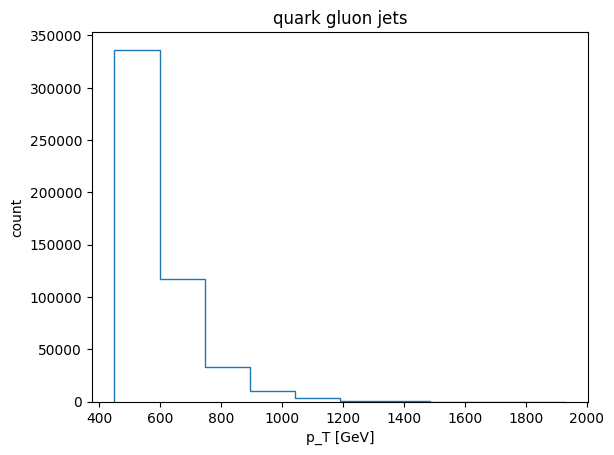

In [4]:
from matplotlib import pyplot

pyplot.title("quark gluon jets")
pyplot.hist(jet_properties_global_quark_gluon["pt"], histtype="step")
pyplot.xlabel("p_T [GeV]")
pyplot.ylabel("count")

The first three files on the other hand contain the four-momenta of the jet constituents (of the individual
particles that make up the jet), ordered by their transverse momentum $p_T$, for each associated type of jet.
These are parameterized by the transverse momentum ($p_T$), the pseudorapidity ($eta$),
the polar angle ($phi$) and the mass of the jet ($m$), in that exact order.
Here the transverse momentum describes the momentum directed towards the cylindrical detector, as opposed to
parallel to the beam line, while the pseudorapidity

$$ \eta = -\ln(\tan \frac{\theta}{2}) $$

is a proxy for the azimuthal angle $\theta$, while differences of $\eta$ (unlike $\theta$) are Lorentz-invariant.
These four quantities are equivalent to the standard representation $(E, p_x, p_y, p_z)$ of a four-momentum and
can be converted to it, using the following formulas

$$ p_x = p_T \cos\phi $$
$$ p_y = p_T \sin\phi $$
$$ p_z = p_T \sinh\eta $$
$$ E = \sqrt{m^2 + p_T^2 \cosh^2\eta} $$

Note that $p_T$ and $m$ are in `\text{GeV}`, while `\theta` and `\phi` are unitless.

Let's have a look with h5py:

In [5]:
import h5py
import numpy
from pathlib import Path

data_folder = Path("data")


with h5py.File(DATA_DIR_PATH / "jet_constituents_quark_gluon.h5") as f:
    jet_constituents_quark_gluon = numpy.array(f["constituents"])
print(jet_constituents_quark_gluon.shape)

(500000, 20, 4)


Looks like we have 500000 jets in here, with one four-momenta stored for every one of 20 constituents per jet.
Let's try to plot the $\eta$, $\phi$ positions of the first jet constituent, using small or large circles
depending on the $p_T$ value.
Let's also show the position and $p_T$ of the full jet for comparison:

Text(0, 0.5, '$\\phi$')

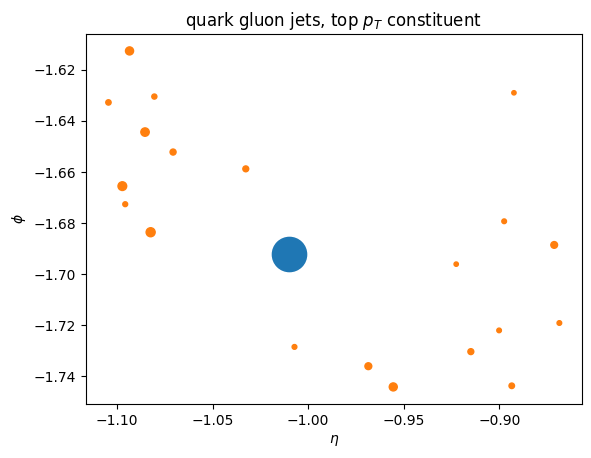

In [6]:
from matplotlib import pyplot

pyplot.title("quark gluon jets, top $p_T$ constituent")
pyplot.scatter(
    jet_properties_global_quark_gluon.eta[0],
    jet_properties_global_quark_gluon.phi[0],
    s=jet_properties_global_quark_gluon.pt[0]
)
pyplot.scatter(
    jet_constituents_quark_gluon[0, :, 1],
    jet_constituents_quark_gluon[0, :, 2],
    s=jet_constituents_quark_gluon[0, :, 0]
)
pyplot.xlabel(r"$\eta$")
pyplot.ylabel(r"$\phi$")

Think of why it makes sense to use $\eta$ and $\phi$ for the position of the constituents here.
The pseudorapidity $\eta$ is essentially a proxy for the position along the beam axis, while
$\phi$ describes the angle in the plane perpendicular of the beam axis.
Together they essentially give you the position on the surface of the cylindrical ATLAS detector
of each jet constituent, while the $p_T$ gives you the momentum perpendicular to that surface.
Think about if this current data representation makes sense for classifying the jet.
Does the label of the jet depend on it's global position?

This hopefully gives you a good idea about how to download and inspect the data.

## Tasks
In this project you will be given 3 pre-defined tasks.
You will be graded on how well you solve them,
on the structure, documentation and reproducilibity of your code
and how well you analyze and present the results of the tasks.
In particular honest analysis of sub-optimal results will give you
a better grade than a sugarcoated description of such.

### Task 1: Binary Classification
Implement data preparation steps and train a binary classification model on prepared quark/gluon vs. W/Z or
top jets, which can reproduce with high accuracy the correct origin of the jet.
The model should work both on quark/gluon vs. W/Z and quark/gluon vs. top jets.
Analyze the performance of the classification model usings metrics of your choice and try to improve sub-optimal
performance as much as possible.

### Task 2: Multi-Class Classification
Implement data preparation steps and train a mutli-class classification model on prepared quark/gluon, W/Z and
top jets, which can reproduce with high accuracy the correct origin of the jet.
Analyze the performance of the classification model usings metrics of your choice and try to improve sub-optimal
performance as much as possible.

### Task 3: Decorrelation
Try to decorrelate the predicted jet origin from the jet's four momentum, i.e. make the classifier ideally only
sensitive to substructure variables, but not to the global four momentum of the jet.
Analyze the how well the model manages to ignore the jet momentum will still achieving good performance on
task 2, using metrics of your choice and improve your method as much as possible.

## Submission
For the submission, we expect you to submit your code and the presentation slides which you will use during the
oral exam in pdf format.

When submitting your code, remember that you are graded on structure, documentation and reproducibility, essentially the same criteria for publishing any kind of code. This means you should have a clear structure and documentation for how the code works, and how to use it to reproduce the results.

For submission please create a folder called `submission`, move all of your relevant code files into that folder
as well as a `presentation.pdf` file containing your presentation slides.
Next, make sure you have done the following beforehand:
- Document code using docstrings for details and a README.md for an introduction and usage/reproduction instructions.
- delete all unnecessary files in `submission`, this include:
    - all data files.
    - the `.git/` folder if it exists.
    - virtual environment folders (generally named `.venv/`). Exercises from previous weeks, only submit code relevant to this project.
    - anything larger than a couple of megabytes, that isn't essential.
    - all plots, unless used as part of the `README.md`.
    - all code that is no longer used.

Finally, convert the `submission` folder into a zip archive (e.g. with `zip -r submission.zip submission` in bash)
called `submission.zip`, double check that everything is in there and upload it on moodle as your final project
submission before the deadline (remember that late submission result in grade reductions, so please submit on time).

In [ ]:
# Task 1: Binary classification of quark/gluon jets against W/Z and top jets

from pathlib import Path

import numpy
import pandas
from matplotlib import pyplot
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

DATA_DIR_PATH = Path("data")
RANDOM_STATE = 7
SAMPLE_SIZE_PER_CLASS = 100_000


def load_global_properties(jet_kind: str) -> pandas.DataFrame:
    """Load the tabular jet-level features for one jet origin."""
    return pandas.read_hdf(
        DATA_DIR_PATH / f"jet_properties_global_{jet_kind}.h5",
        key="substructure",
    )


def prepare_binary_features(jets: pandas.DataFrame) -> pandas.DataFrame:
    """Build stable, mostly position-independent features for binary tagging."""
    eps = 1e-8
    features = jets.copy()

    features["tau21"] = features["tau2"] / (features["tau1"] + eps)
    features["tau32"] = features["tau3"] / (features["tau2"] + eps)
    features["d23_over_d12"] = features["d23"] / (features["d12"] + eps)
    features["ecf3_over_ecf2"] = features["ECF3"] / (features["ECF2"] + eps)

    for column in ["pt", "mass", "d12", "d23", "ECF2", "ECF3"]:
        features[f"log_{column}"] = numpy.log1p(features[column].clip(lower=0))

    selected_columns = [
        "pt",
        "mass",
        "tau1",
        "tau2",
        "tau3",
        "tau21",
        "tau32",
        "d12",
        "d23",
        "d23_over_d12",
        "ECF2",
        "ECF3",
        "ecf3_over_ecf2",
        "log_pt",
        "log_mass",
        "log_d12",
        "log_d23",
        "log_ECF2",
        "log_ECF3",
    ]
    return features[selected_columns].replace([numpy.inf, -numpy.inf], numpy.nan).fillna(0.0)


def make_balanced_binary_dataset(
    positive_jet_kind: str,
    n_per_class: int = SAMPLE_SIZE_PER_CLASS,
) -> tuple[pandas.DataFrame, numpy.ndarray]:
    """Create a balanced quark/gluon-vs-signal dataset."""
    rng = numpy.random.default_rng(RANDOM_STATE)
    background = load_global_properties("quark_gluon")
    signal = load_global_properties(positive_jet_kind)
    n_selected = min(n_per_class, len(background), len(signal))

    background_indices = rng.choice(len(background), n_selected, replace=False)
    signal_indices = rng.choice(len(signal), n_selected, replace=False)

    background_features = prepare_binary_features(background.iloc[background_indices])
    signal_features = prepare_binary_features(signal.iloc[signal_indices])

    X = pandas.concat([background_features, signal_features], ignore_index=True)
    y = numpy.concatenate(
        [numpy.zeros(n_selected, dtype=int), numpy.ones(n_selected, dtype=int)]
    )
    return X, y


def train_and_evaluate_binary_model(positive_jet_kind: str) -> dict[str, object]:
    """Train one binary classifier and return the model plus performance metrics."""
    X, y = make_balanced_binary_dataset(positive_jet_kind)
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    model = HistGradientBoostingClassifier(
        max_iter=180,
        learning_rate=0.08,
        l2_regularization=0.02,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    task_name = f"quark/gluon vs {positive_jet_kind}"

    print(f"\n{task_name}")
    print(classification_report(
        y_test,
        predictions,
        target_names=["quark/gluon", positive_jet_kind],
    ))

    return {
        "task": task_name,
        "model": model,
        "X_test": X_test,
        "y_test": y_test,
        "probabilities": probabilities,
        "predictions": predictions,
        "accuracy": accuracy_score(y_test, predictions),
        "f1": f1_score(y_test, predictions),
        "roc_auc": roc_auc_score(y_test, probabilities),
        "average_precision": average_precision_score(y_test, probabilities),
    }


task1_evaluations = [
    train_and_evaluate_binary_model("wz"),
    train_and_evaluate_binary_model("top"),
]

fig, axes = pyplot.subplots(2, 2, figsize=(12, 9))
for row_index, evaluation in enumerate(task1_evaluations):
    positive_label = evaluation["task"].split(" vs ")[1]
    ConfusionMatrixDisplay.from_predictions(
        evaluation["y_test"],
        evaluation["predictions"],
        display_labels=["quark/gluon", positive_label],
        normalize="true",
        ax=axes[row_index, 0],
        colorbar=False,
    )
    axes[row_index, 0].set_title(f"{evaluation['task']} confusion matrix")

    RocCurveDisplay.from_predictions(
        evaluation["y_test"],
        evaluation["probabilities"],
        ax=axes[row_index, 1],
    )
    axes[row_index, 1].set_title(f"{evaluation['task']} ROC curve")

pyplot.tight_layout()

task1_results = pandas.DataFrame(
    [
        {
            metric: evaluation[metric]
            for metric in ["task", "accuracy", "f1", "roc_auc", "average_precision"]
        }
        for evaluation in task1_evaluations
    ]
).set_index("task")
task1_models = {evaluation["task"]: evaluation["model"] for evaluation in task1_evaluations}
task1_results

In [ ]:
# Task 2: Multi-class classification of quark/gluon, W/Z, and top jets

from pathlib import Path

import h5py
import numpy
import pandas
from matplotlib import pyplot
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

DATA_DIR_PATH = Path("data")
RANDOM_STATE = 7
TASK2_SAMPLE_SIZE_PER_CLASS = 75_000
TASK2_LABELS = ["quark_gluon", "wz", "top"]
TASK2_DISPLAY_LABELS = ["quark/gluon", "W/Z", "top"]


def load_task2_global_properties(jet_kind: str) -> pandas.DataFrame:
    """Load the global jet-level table for one jet class."""
    return pandas.read_hdf(
        DATA_DIR_PATH / f"jet_properties_global_{jet_kind}.h5",
        key="substructure",
    )


def prepare_task2_global_features(jets: pandas.DataFrame) -> pandas.DataFrame:
    """Prepare jet-level features, including classic subjetiness ratios."""
    eps = 1e-8
    features = jets.copy()
    features["tau21"] = features["tau2"] / (features["tau1"] + eps)
    features["tau32"] = features["tau3"] / (features["tau2"] + eps)
    features["d23_over_d12"] = features["d23"] / (features["d12"] + eps)
    features["ecf3_over_ecf2"] = features["ECF3"] / (features["ECF2"] + eps)

    for column in ["pt", "mass", "d12", "d23", "ECF2", "ECF3"]:
        features[f"log_{column}"] = numpy.log1p(features[column].clip(lower=0))

    selected_columns = [
        "pt",
        "mass",
        "tau1",
        "tau2",
        "tau3",
        "tau21",
        "tau32",
        "d12",
        "d23",
        "d23_over_d12",
        "ECF2",
        "ECF3",
        "ecf3_over_ecf2",
        "log_pt",
        "log_mass",
        "log_d12",
        "log_d23",
        "log_ECF2",
        "log_ECF3",
    ]
    return features[selected_columns].replace([numpy.inf, -numpy.inf], numpy.nan).fillna(0.0)


def prepare_task2_constituent_features(
    jet_kind: str,
    selected_indices: numpy.ndarray,
    selected_jets: pandas.DataFrame,
) -> pandas.DataFrame:
    """Represent constituents relative to the jet axis so global detector position is not used."""
    with h5py.File(DATA_DIR_PATH / f"jet_constituents_{jet_kind}.h5") as h5_file:
        constituents = numpy.array(h5_file["constituents"][selected_indices])

    constituent_pt = constituents[:, :, 0]
    constituent_eta = constituents[:, :, 1]
    constituent_phi = constituents[:, :, 2]
    constituent_mass = constituents[:, :, 3]

    jet_pt = selected_jets["pt"].to_numpy()[:, numpy.newaxis]
    jet_eta = selected_jets["eta"].to_numpy()[:, numpy.newaxis]
    jet_phi = selected_jets["phi"].to_numpy()[:, numpy.newaxis]

    pt_fraction = constituent_pt / (jet_pt + 1e-8)
    delta_eta = constituent_eta - jet_eta
    delta_phi = (constituent_phi - jet_phi + numpy.pi) % (2 * numpy.pi) - numpy.pi

    feature_columns = {}
    for constituent_index in range(constituents.shape[1]):
        prefix = f"constituent_{constituent_index:02d}"
        feature_columns[f"{prefix}_pt_fraction"] = pt_fraction[:, constituent_index]
        feature_columns[f"{prefix}_delta_eta"] = delta_eta[:, constituent_index]
        feature_columns[f"{prefix}_delta_phi"] = delta_phi[:, constituent_index]
        feature_columns[f"{prefix}_mass"] = constituent_mass[:, constituent_index]

    pt_fraction_sum = pt_fraction.sum(axis=1)
    feature_columns["constituent_pt_fraction_sum"] = pt_fraction_sum
    feature_columns["constituent_pt_fraction_std"] = pt_fraction.std(axis=1)
    feature_columns["constituent_delta_eta_pt_weighted_mean"] = (
        delta_eta * pt_fraction
    ).sum(axis=1) / (pt_fraction_sum + 1e-8)
    feature_columns["constituent_delta_phi_pt_weighted_mean"] = (
        delta_phi * pt_fraction
    ).sum(axis=1) / (pt_fraction_sum + 1e-8)

    return pandas.DataFrame(feature_columns).replace(
        [numpy.inf, -numpy.inf], numpy.nan
    ).fillna(0.0)


def make_task2_multiclass_dataset(
    n_per_class: int = TASK2_SAMPLE_SIZE_PER_CLASS,
) -> tuple[pandas.DataFrame, numpy.ndarray]:
    """Build a balanced three-class dataset from the global and constituent files."""
    rng = numpy.random.default_rng(RANDOM_STATE)
    feature_frames = []
    target_arrays = []

    for class_index, jet_kind in enumerate(TASK2_LABELS):
        global_properties = load_task2_global_properties(jet_kind)
        n_selected = min(n_per_class, len(global_properties))
        selected_indices = numpy.sort(
            rng.choice(len(global_properties), n_selected, replace=False)
        )
        selected_jets = global_properties.iloc[selected_indices].reset_index(drop=True)

        global_features = prepare_task2_global_features(selected_jets).reset_index(drop=True)
        constituent_features = prepare_task2_constituent_features(
            jet_kind,
            selected_indices,
            selected_jets,
        )
        feature_frames.append(
            pandas.concat([global_features, constituent_features], axis=1)
        )
        target_arrays.append(numpy.full(n_selected, class_index, dtype=int))

    X = pandas.concat(feature_frames, ignore_index=True)
    y = numpy.concatenate(target_arrays)
    return X, y


X_task2, y_task2 = make_task2_multiclass_dataset()
X_task2_train, X_task2_test, y_task2_train, y_task2_test = train_test_split(
    X_task2,
    y_task2,
    test_size=0.25,
    stratify=y_task2,
    random_state=RANDOM_STATE,
)

task2_model = HistGradientBoostingClassifier(
    max_iter=220,
    learning_rate=0.08,
    l2_regularization=0.02,
    random_state=RANDOM_STATE,
)
task2_model.fit(X_task2_train, y_task2_train)

task2_probabilities = task2_model.predict_proba(X_task2_test)
task2_predictions = task2_probabilities.argmax(axis=1)

print(classification_report(
    y_task2_test,
    task2_predictions,
    target_names=TASK2_DISPLAY_LABELS,
))

ConfusionMatrixDisplay.from_predictions(
    y_task2_test,
    task2_predictions,
    display_labels=TASK2_DISPLAY_LABELS,
    normalize="true",
    cmap="Blues",
)
pyplot.title("Task 2 normalized confusion matrix")
pyplot.tight_layout()

task2_results = pandas.DataFrame(
    [
        {
            "accuracy": accuracy_score(y_task2_test, task2_predictions),
            "macro_f1": f1_score(y_task2_test, task2_predictions, average="macro"),
            "weighted_f1": f1_score(y_task2_test, task2_predictions, average="weighted"),
            "macro_roc_auc_ovr": roc_auc_score(
                y_task2_test,
                task2_probabilities,
                multi_class="ovr",
                average="macro",
            ),
        }
    ]
)
task2_results

In [ ]:
# Task 3: Momentum-decorrelated multi-class classification

from pathlib import Path

import h5py
import numpy
import pandas
from matplotlib import pyplot
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

DATA_DIR_PATH = Path("data")
RANDOM_STATE = 7
TASK3_LABELS = ["quark_gluon", "wz", "top"]
TASK3_DISPLAY_LABELS = ["quark/gluon", "W/Z", "top"]
TASK3_MOMENTUM_COLUMNS = ["pt", "eta", "phi", "mass"]


# The main decorrelation idea is deliberately simple and auditable:
# 1. never give the classifier direct global four-momentum inputs;
# 2. use relative constituent coordinates instead of absolute eta/phi;
# 3. train and test on a dataset equalized across classes in common (pt, mass) bins.
# The last step prevents the classifier from learning class labels through the different
# momentum spectra of the three samples.


def load_task3_global_properties(jet_kind: str) -> pandas.DataFrame:
    """Load the global jet-level table for one jet origin."""
    return pandas.read_hdf(
        DATA_DIR_PATH / f"jet_properties_global_{jet_kind}.h5",
        key="substructure",
    )


def prepare_task3_substructure_features(jets: pandas.DataFrame) -> pandas.DataFrame:
    """Use mostly unitless substructure features and omit pt, eta, phi, and mass."""
    eps = 1e-8
    features = pandas.DataFrame(index=jets.index)
    features["tau1"] = jets["tau1"]
    features["tau2"] = jets["tau2"]
    features["tau3"] = jets["tau3"]
    features["tau21"] = jets["tau2"] / (jets["tau1"] + eps)
    features["tau32"] = jets["tau3"] / (jets["tau2"] + eps)
    features["d23_over_d12"] = jets["d23"] / (jets["d12"] + eps)
    features["ecf3_over_ecf2"] = jets["ECF3"] / (jets["ECF2"] + eps)
    return features.replace([numpy.inf, -numpy.inf], numpy.nan).fillna(0.0)


def prepare_task3_constituent_features(
    jet_kind: str,
    selected_indices: numpy.ndarray,
    selected_jets: pandas.DataFrame,
) -> pandas.DataFrame:
    """Encode constituents only by pt fractions and positions relative to the jet axis."""
    with h5py.File(DATA_DIR_PATH / f"jet_constituents_{jet_kind}.h5") as h5_file:
        constituents = numpy.array(h5_file["constituents"][selected_indices])

    constituent_pt = constituents[:, :, 0]
    constituent_eta = constituents[:, :, 1]
    constituent_phi = constituents[:, :, 2]

    jet_pt = selected_jets["pt"].to_numpy()[:, numpy.newaxis]
    jet_eta = selected_jets["eta"].to_numpy()[:, numpy.newaxis]
    jet_phi = selected_jets["phi"].to_numpy()[:, numpy.newaxis]

    pt_fraction = constituent_pt / (jet_pt + 1e-8)
    delta_eta = constituent_eta - jet_eta
    delta_phi = (constituent_phi - jet_phi + numpy.pi) % (2 * numpy.pi) - numpy.pi
    radius = numpy.sqrt(delta_eta**2 + delta_phi**2)

    feature_columns = {}
    for constituent_index in range(constituents.shape[1]):
        prefix = f"constituent_{constituent_index:02d}"
        feature_columns[f"{prefix}_pt_fraction"] = pt_fraction[:, constituent_index]
        feature_columns[f"{prefix}_delta_eta"] = delta_eta[:, constituent_index]
        feature_columns[f"{prefix}_delta_phi"] = delta_phi[:, constituent_index]
        feature_columns[f"{prefix}_radius"] = radius[:, constituent_index]

    pt_fraction_sum = pt_fraction.sum(axis=1)
    radius_weighted_mean = (radius * pt_fraction).sum(axis=1) / (pt_fraction_sum + 1e-8)
    feature_columns["constituent_pt_fraction_sum"] = pt_fraction_sum
    feature_columns["constituent_pt_fraction_std"] = pt_fraction.std(axis=1)
    feature_columns["constituent_radius_pt_weighted_mean"] = radius_weighted_mean
    feature_columns["constituent_radius_pt_weighted_std"] = numpy.sqrt(
        (((radius - radius_weighted_mean[:, numpy.newaxis]) ** 2) * pt_fraction).sum(axis=1)
        / (pt_fraction_sum + 1e-8)
    )

    return pandas.DataFrame(feature_columns).replace(
        [numpy.inf, -numpy.inf], numpy.nan
    ).fillna(0.0)


def select_momentum_balanced_indices(
    global_properties_by_class: dict[str, pandas.DataFrame],
    n_bins: int = 5,
    max_per_bin_per_class: int = 4_000,
    min_per_bin_per_class: int = 25,
) -> dict[str, numpy.ndarray]:
    """Select equal class counts in shared pt/mass bins."""
    rng = numpy.random.default_rng(RANDOM_STATE)
    pooled_momenta = pandas.concat(
        [
            global_properties_by_class[jet_kind][["pt", "mass"]]
            for jet_kind in TASK3_LABELS
        ],
        ignore_index=True,
    )
    pt_edges = numpy.unique(numpy.quantile(pooled_momenta["pt"], numpy.linspace(0, 1, n_bins + 1)))
    mass_edges = numpy.unique(numpy.quantile(pooled_momenta["mass"], numpy.linspace(0, 1, n_bins + 1)))
    pt_edges[0] -= 1e-6
    pt_edges[-1] += 1e-6
    mass_edges[0] -= 1e-6
    mass_edges[-1] += 1e-6

    selected_indices_by_class = {jet_kind: [] for jet_kind in TASK3_LABELS}
    for pt_bin in range(len(pt_edges) - 1):
        for mass_bin in range(len(mass_edges) - 1):
            candidate_indices_by_class = []
            for jet_kind in TASK3_LABELS:
                global_properties = global_properties_by_class[jet_kind]
                in_bin = (
                    (global_properties["pt"] >= pt_edges[pt_bin])
                    & (global_properties["pt"] < pt_edges[pt_bin + 1])
                    & (global_properties["mass"] >= mass_edges[mass_bin])
                    & (global_properties["mass"] < mass_edges[mass_bin + 1])
                )
                candidate_indices_by_class.append(numpy.flatnonzero(in_bin.to_numpy()))

            n_selected = min(
                [len(indices) for indices in candidate_indices_by_class]
                + [max_per_bin_per_class]
            )
            if n_selected < min_per_bin_per_class:
                continue

            for jet_kind, candidate_indices in zip(TASK3_LABELS, candidate_indices_by_class):
                selected_indices_by_class[jet_kind].append(
                    rng.choice(candidate_indices, n_selected, replace=False)
                )

    return {
        jet_kind: numpy.sort(numpy.concatenate(index_chunks))
        for jet_kind, index_chunks in selected_indices_by_class.items()
    }


def make_task3_decorrelated_dataset() -> tuple[pandas.DataFrame, numpy.ndarray, pandas.DataFrame]:
    """Build the decorrelated feature matrix, labels, and held-out momentum audit columns."""
    global_properties_by_class = {
        jet_kind: load_task3_global_properties(jet_kind)
        for jet_kind in TASK3_LABELS
    }
    selected_indices_by_class = select_momentum_balanced_indices(global_properties_by_class)

    feature_frames = []
    target_arrays = []
    momentum_frames = []
    for class_index, jet_kind in enumerate(TASK3_LABELS):
        selected_indices = selected_indices_by_class[jet_kind]
        selected_jets = global_properties_by_class[jet_kind].iloc[selected_indices].reset_index(drop=True)

        substructure_features = prepare_task3_substructure_features(selected_jets).reset_index(drop=True)
        constituent_features = prepare_task3_constituent_features(
            jet_kind,
            selected_indices,
            selected_jets,
        )
        feature_frames.append(
            pandas.concat([substructure_features, constituent_features], axis=1)
        )
        target_arrays.append(numpy.full(len(selected_indices), class_index, dtype=int))
        momentum_frames.append(selected_jets[TASK3_MOMENTUM_COLUMNS])

    X = pandas.concat(feature_frames, ignore_index=True)
    y = numpy.concatenate(target_arrays)
    momenta = pandas.concat(momentum_frames, ignore_index=True)
    return X, y, momenta


def probability_momentum_correlations(
    probabilities: numpy.ndarray,
    momenta: pandas.DataFrame,
) -> pandas.DataFrame:
    """Measure linear dependence between each class probability and momentum variable."""
    rows = []
    for class_index, class_name in enumerate(TASK3_DISPLAY_LABELS):
        row = {"class": class_name}
        for momentum_column in TASK3_MOMENTUM_COLUMNS:
            row[f"abs_corr_probability_{momentum_column}"] = abs(
                numpy.corrcoef(probabilities[:, class_index], momenta[momentum_column])[0, 1]
            )
        rows.append(row)
    return pandas.DataFrame(rows).set_index("class")


def prediction_momentum_eta_squared(
    predictions: numpy.ndarray,
    momenta: pandas.DataFrame,
) -> pandas.DataFrame:
    """Correlation ratio eta^2: how much momentum variance is explained by predicted class."""
    rows = []
    for momentum_column in TASK3_MOMENTUM_COLUMNS:
        values = momenta[momentum_column].to_numpy()
        grand_mean = values.mean()
        total_sum_squares = ((values - grand_mean) ** 2).sum()
        between_sum_squares = 0.0
        for predicted_class in numpy.unique(predictions):
            group_values = values[predictions == predicted_class]
            between_sum_squares += len(group_values) * (group_values.mean() - grand_mean) ** 2
        rows.append(
            {
                "momentum_variable": momentum_column,
                "eta_squared_predicted_class": between_sum_squares / total_sum_squares,
            }
        )
    return pandas.DataFrame(rows).set_index("momentum_variable")


X_task3, y_task3, task3_momenta = make_task3_decorrelated_dataset()
(
    X_task3_train,
    X_task3_test,
    y_task3_train,
    y_task3_test,
    task3_momenta_train,
    task3_momenta_test,
) = train_test_split(
    X_task3,
    y_task3,
    task3_momenta,
    test_size=0.25,
    stratify=y_task3,
    random_state=RANDOM_STATE,
)

task3_model = HistGradientBoostingClassifier(
    max_iter=220,
    learning_rate=0.08,
    l2_regularization=0.08,
    random_state=RANDOM_STATE,
)
task3_model.fit(X_task3_train, y_task3_train)

task3_probabilities = task3_model.predict_proba(X_task3_test)
task3_predictions = task3_probabilities.argmax(axis=1)

print(classification_report(
    y_task3_test,
    task3_predictions,
    target_names=TASK3_DISPLAY_LABELS,
))

fig, axes = pyplot.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_task3_test,
    task3_predictions,
    display_labels=TASK3_DISPLAY_LABELS,
    normalize="true",
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Task 3 normalized confusion matrix")

task3_momenta_test.assign(predicted_class=task3_predictions).boxplot(
    column="mass",
    by="predicted_class",
    ax=axes[1],
)
axes[1].set_title("Jet mass by predicted class after decorrelation")
axes[1].set_xlabel("predicted class index")
axes[1].set_ylabel("mass [GeV]")
fig.suptitle("")
pyplot.tight_layout()

task3_results = pandas.DataFrame(
    [
        {
            "accuracy": accuracy_score(y_task3_test, task3_predictions),
            "macro_f1": f1_score(y_task3_test, task3_predictions, average="macro"),
            "weighted_f1": f1_score(y_task3_test, task3_predictions, average="weighted"),
            "macro_roc_auc_ovr": roc_auc_score(
                y_task3_test,
                task3_probabilities,
                multi_class="ovr",
                average="macro",
            ),
            "n_train": len(y_task3_train),
            "n_test": len(y_task3_test),
            "n_features": X_task3.shape[1],
        }
    ]
)
task3_probability_momentum_correlations = probability_momentum_correlations(
    task3_probabilities,
    task3_momenta_test,
)
task3_prediction_momentum_eta_squared = prediction_momentum_eta_squared(
    task3_predictions,
    task3_momenta_test,
)

display(task3_results)
display(task3_probability_momentum_correlations)
display(task3_prediction_momentum_eta_squared)